# ResNet50 파인튜닝

In [1]:
# warings 출력안하기
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import tensorflow as tf

I0000 00:00:1788329181.512531   13892 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788329182.664581   13892 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import decode_predictions
import numpy as np

## 사전 학습 모델 로딩

In [3]:
# ImageNet"이라는 대규모 이미지 데이터셋으로 사전 학습(pre-trained)된 가중치를 불러오겠다는 뜻
model = ResNet50(weights='imagenet') # 첫 실행 시 가중치 다운로드됨

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## 테스트 데이터 준비

In [4]:
# https://commons.wikimedia.org/wiki/File:YellowLabradorLooking_new.jpg
img = image.load_img('image_data/sample.jpg',target_size=(224, 224))

In [5]:
x = image.img_to_array(img)     # x.shape=(224,224,3)
x = np.expand_dims(x, axis=0)   # x.shape=(1,244,244,3)

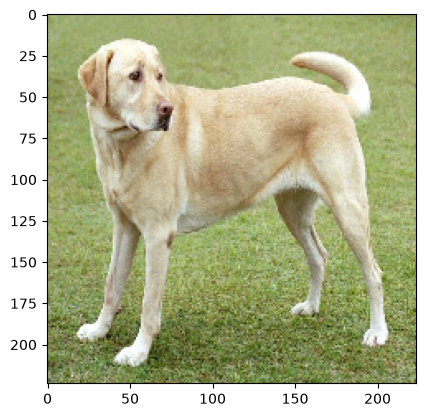

In [6]:
# 이미지 확인
import matplotlib.pyplot as plt
plt.imshow(img)

## 예측수행

In [7]:
pred = model.predict(x, verbose=0)
print('Predicted:', decode_predictions(pred, top=3))

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.26892254)), ('n02108089', 'boxer', np.float32(0.15144922)), ('n02099849', 'Chesapeake_Bay_retriever', np.float32(0.10761134))]]


# 전이학습

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# include_top=False : ImageNet 분류층(1000개)을 떼고 특징 추출부만 사용
# input_shape=(224,224,3) : ResNet50 기본 입력 크기
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False          # 1단계 : 사전학습 가중치 동결(freeze)

# 새 분류 헤드 (녹내장 3-클래스 다중분류)
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(3, activation='softmax')(x)

resnet_model = Model(base.input, out)
model = resnet_model              # 아래 셀들과 이름 통일
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# 증강 데이터로 파인튜닝하기

### 데이터 압축풀기

In [9]:
import zipfile

file_path = 'image_data/glaucoma.zip' # 업로드한 zip 파일의 이름으로 변경

# zip 파일 압축 해제
with zipfile.ZipFile(file_path, 'r') as f:
    f.extractall('./image_data' )

## 학습데이터 증강

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# ★ ResNet50 전용 전처리(preprocess_input)를 반드시 적용
#   (0~255 원본값을 그대로 넣으면 loss가 발산함)
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               rotation_range=15,
                               width_shift_range=0.1, height_shift_range=0.1,
                               zoom_range=0.1, horizontal_flip=True,
                               fill_mode='reflect')
train_data = train_gen.flow_from_directory('image_data/glaucoma/train', target_size=(224,224),
                                           batch_size=32, class_mode='sparse',
                                           shuffle=True, seed=42)

# 검증/평가용은 증강 없이 전처리만, shuffle=False (classification_report 순서 일치)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_data = test_gen.flow_from_directory('image_data/glaucoma/test', target_size=(224,224),
                                         batch_size=32, class_mode='sparse',
                                         shuffle=False)

Found 1394 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


## 파인튜닝하기

- cpu에서 하면, 학습시간 1시간이상 걸림
- GPU에서 하면, 학습시간 6분내외

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# 클래스 불균형 보정 (early_glaucoma 표본이 적어 recall 0 이 되는 문제 방지)
cw = compute_class_weight('balanced', classes=np.arange(3), y=train_data.classes)
class_weight = {i: w for i, w in enumerate(cw)}
print('class_weight:', class_weight)

# val_accuracy 가 가장 높은 시점의 모델을 best model 로 저장
ckpt = ModelCheckpoint('best_glaucoma_resnet50.keras',
                       monitor='val_accuracy', mode='max', save_best_only=True)

# ===== Phase 1 : 헤드만 학습 (base 동결) =====
# 성능 최적화 알고리즘 : adam, loss : sparse_categorical_crossentropy, metrics : accuracy
model.compile(optimizer=Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=test_data, epochs=15,
          class_weight=class_weight,
          callbacks=[ckpt, ReduceLROnPlateau(monitor='val_accuracy', mode='max',
                                             patience=5, factor=0.5, min_lr=1e-5)])

# ===== Phase 2 : conv4 + conv5 블록만 미세조정 (BN 층은 계속 동결) =====
base.trainable = True
for layer in base.layers:
    if not (layer.name.startswith('conv4') or layer.name.startswith('conv5')):
        layer.trainable = False
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=Adam(2e-5),          # 미세조정은 아주 작은 학습률
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=test_data, epochs=35,
          class_weight=class_weight,
          callbacks=[ckpt,
                     EarlyStopping(monitor='val_accuracy', mode='max', patience=14,
                                   restore_best_weights=True),
                     ReduceLROnPlateau(monitor='val_accuracy', mode='max',
                                       patience=6, factor=0.5, min_lr=1e-7)])


class_weight: {0: np.float64(1.1037212984956453), 1: np.float64(1.7667934093789608), 2: np.float64(0.6544600938967137)}
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 578ms/step - accuracy: 0.5631 - loss: 1.2911 - val_accuracy: 0.5933 - val_loss: 0.8296 - learning_rate: 0.0010
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.6686 - loss: 0.7819 - val_accuracy: 0.6800 - val_loss: 0.7724 - learning_rate: 0.0010
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.7138 - loss: 0.6895 - val_accuracy: 0.6533 - val_loss: 0.7834 - learning_rate: 0.0010
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.7166 - loss: 0.6636 - val_accuracy: 0.6933 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.7267 - loss: 0.6609 - val_accuracy: 0.6867 - val_loss: 0.7942 - learning_rate: 0.0010
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.7339 - loss: 0.6448 - val_accuracy: 0.6867 - val_l

## 학습 모델 테스트하기

In [12]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

# 학습 중 저장해 둔 best model 로딩
model = tf.keras.models.load_model('best_glaucoma_resnet50.keras')

# test.png 데이터 로딩
img = image.load_img('image_data/test.png', target_size=(224, 224))

# numpy 객체로 변환 + ResNet50 전처리(학습과 동일하게)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# test.png는 early glaucoma, 1  <- 녹내장
class_names = [name for name, idx in sorted(train_data.class_indices.items(), key=lambda x: x[1])]
pred = model.predict(x)
print(pred, '->', class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[2.2479791e-05 9.9993837e-01 3.9104962e-05]] -> early_glaucoma


## 모델 평가하기

In [13]:
# test_data는 내부적으로 이미 (X, y)를 포함하고 있는 제너레이터 객체 (DirectoryIterator)
loss, accuracy = model.evaluate(test_data)
print(f'Test loss: {loss}, Test accuracy: {accuracy}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.8067 - loss: 0.9404
Test loss: 0.9404210448265076, Test accuracy: 0.8066666722297668


## 모델 평가 요약

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# best model 로 평가
model = tf.keras.models.load_model('best_glaucoma_resnet50.keras')

# 클래스 인덱스 -> 클래스 이름 (인덱스 순서대로 정렬)
class_names = [name for name, idx in sorted(test_data.class_indices.items(), key=lambda x: x[1])]

# test_data(DirectoryIterator, shuffle=False)를 한 바퀴 순회하며 실제값/예측값 수집
y_true = []
y_pred = []
for i in range(len(test_data)):
    x_batch, y_batch = test_data[i]          # class_mode='sparse' -> y_batch: 정수 라벨
    prob = model.predict(x_batch, verbose=0)  # (batch, 3) 확률
    y_true.extend(y_batch.astype(int).tolist())
    y_pred.extend(np.argmax(prob, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 혼동행렬 + 분류 성능 요약 출력 (accuracy / recall 확인)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

[[42  1  3]
 [ 5 18  3]
 [ 3 14 61]]
                   precision    recall  f1-score   support

advanced_glaucoma     0.8400    0.9130    0.8750        46
   early_glaucoma     0.5455    0.6923    0.6102        26
   normal_control     0.9104    0.7821    0.8414        78

         accuracy                         0.8067       150
        macro avg     0.7653    0.7958    0.7755       150
     weighted avg     0.8256    0.8067    0.8116       150



[[42  1  3]
 [ 5 18  3]
 [ 3 14 61]]
                   precision    recall  f1-score   support

advanced_glaucoma     0.8400    0.9130    0.8750        46
   early_glaucoma     0.5455    0.6923    0.6102        26
   normal_control     0.9104    0.7821    0.8414        78

         accuracy                         0.8067       150
        macro avg     0.7653    0.7958    0.7755       150
     weighted avg     0.8256    0.8067    0.8116       150